In [4]:
import warnings
from sklearn import metrics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rc('font', size=14)
import seaborn as sns
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import scale
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools import add_constant
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from sklearn import metrics
import statsmodels.stats.api as sms
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score, classification_report
from sklearn.naive_bayes import GaussianNB

In [5]:
data=pd.read_csv('German_Credit.csv')
data.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk,Purpose
0,67,male,skilled,own,little,little,1169,6,0,radio/TV
1,22,female,skilled,own,little,moderate,5951,48,1,radio/TV
2,49,male,unskilled_and_non-resident,own,little,little,2096,12,0,education
3,45,male,skilled,free,little,little,7882,42,0,furniture/equipment
4,53,male,skilled,free,little,little,4870,24,1,car


In [6]:
data.isnull().sum()

Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Risk                0
Purpose             0
dtype: int64

In [7]:
data.isna().sum()

Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Risk                0
Purpose             0
dtype: int64

In [8]:
data.isin([0]).sum()

Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts       0
Checking account      0
Credit amount         0
Duration              0
Risk                700
Purpose               0
dtype: int64

In [9]:
df = data.copy()

### Bivariate Analysis

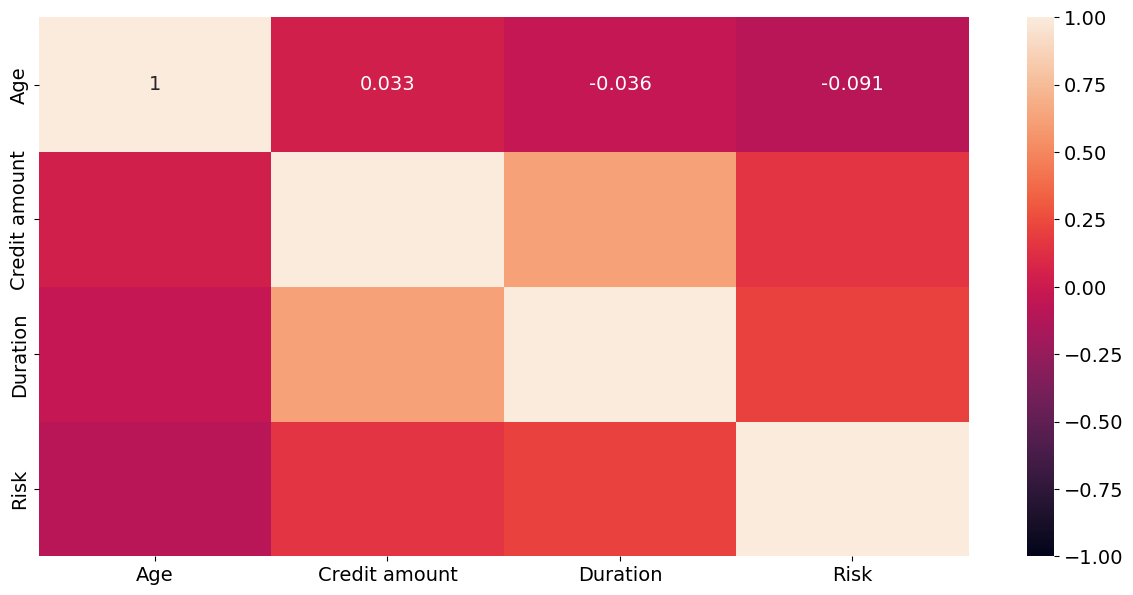

In [10]:
plt.figure(figsize=(15,7))
num_col = data.select_dtypes(include='number')
sns.heatmap(num_col.corr(), vmin=-1, vmax=1, annot=True)
plt.show();

C:\Users\Hrishikesh\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Hrishikesh\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Hrishikesh\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


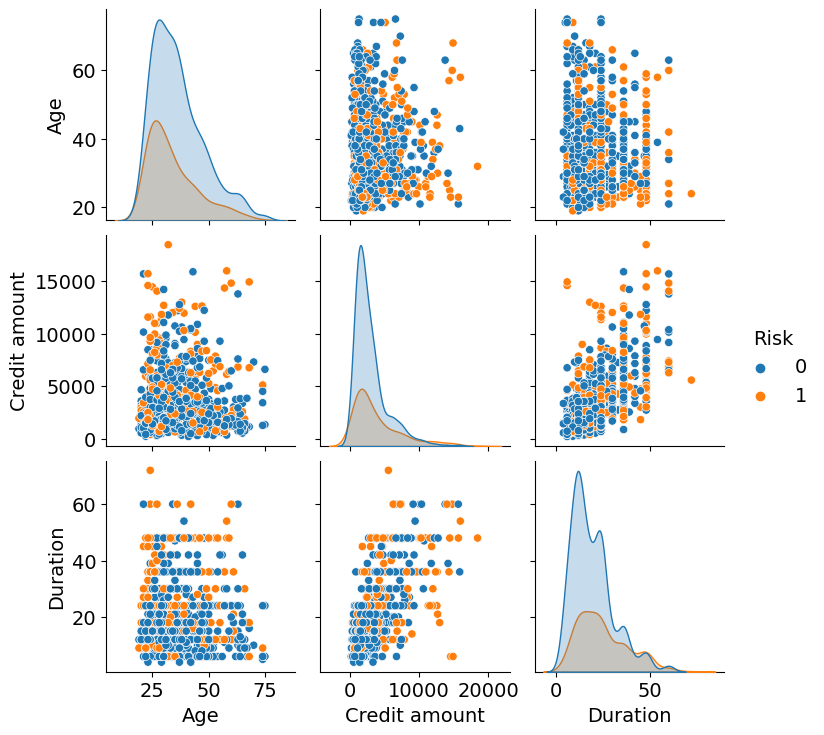

In [11]:
sns.pairplot(data, hue='Risk')
plt.show();

In [12]:
data['Risk'].value_counts(1).round(2)*100

Risk
0    70.0
1    30.0
Name: proportion, dtype: float64

In [13]:
x = data.drop(['Risk'], axis=1)
y = data['Risk']
x = add_constant(x)
x = pd.get_dummies(x, drop_first=True).astype(int)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, stratify = y, random_state=1)

In [14]:
lg = sm.Logit(y_train, x_train).fit()

Optimization terminated successfully.
         Current function value: 0.555034
         Iterations 6


In [15]:
pred_train = np.round(lg.predict(x_train))

In [16]:
print(lg.summary())

                           Logit Regression Results                           
Dep. Variable:                   Risk   No. Observations:                  700
Model:                          Logit   Df Residuals:                      679
Method:                           MLE   Df Model:                           20
Date:                Tue, 22 Apr 2025   Pseudo R-squ.:                 0.09140
Time:                        07:41:37   Log-Likelihood:                -388.52
converged:                       True   LL-Null:                       -427.61
Covariance Type:            nonrobust   LLR p-value:                 8.034e-09
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             -0.4570      0.676     -0.676      0.499      -1.782       0.868
Age                               -0.0144      0.009     -1.665      0.

In [17]:
accuracy_score(y_train, pred_train)

0.7314285714285714

In [18]:
cm = confusion_matrix(y_train, pred_train)
custom_cm = pd.DataFrame([[cm[1,1],cm[1,0]],
                          [cm[0,1],cm[0,0]]],
                         columns = ['Predicted Positive','Predicted Negative'],
                         index = ['Actual Positive','Actual Negative'])
custom_cm

,Predicted Positive,Predicted Negative
Actual Positive,49,161
Actual Negative,27,463


In [19]:
vif_series = pd.Series([variance_inflation_factor(x_train.values, i) for i in range(x_train.shape[1])],
                       index=x_train.columns,
                       dtype=float)
vif_series

const                             61.033616
Age                                1.208115
Credit amount                      1.938675
Duration                           1.763563
Sex_male                           1.115980
Job_skilled                        2.330017
Job_unskilled_and_non-resident     2.290533
Housing_own                        2.663358
Housing_rent                       2.842824
Saving accounts_moderate           1.123223
Saving accounts_quite rich         1.102141
Saving accounts_rich               1.083896
Checking account_moderate          1.286068
Checking account_rich              1.109818
Purpose_car                        3.307761
Purpose_domestic appliances        1.105816
Purpose_education                  1.573499
Purpose_furniture/equipment        2.659096
Purpose_radio/TV                   2.996940
Purpose_repairs                    1.277476
Purpose_vacation/others            1.171315
dtype: float64

In [20]:
print(lg.summary())

                           Logit Regression Results                           
Dep. Variable:                   Risk   No. Observations:                  700
Model:                          Logit   Df Residuals:                      679
Method:                           MLE   Df Model:                           20
Date:                Tue, 22 Apr 2025   Pseudo R-squ.:                 0.09140
Time:                        07:41:38   Log-Likelihood:                -388.52
converged:                       True   LL-Null:                       -427.61
Covariance Type:            nonrobust   LLR p-value:                 8.034e-09
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             -0.4570      0.676     -0.676      0.499      -1.782       0.868
Age                               -0.0144      0.009     -1.665      0.

In [21]:
x_train1 = x_train.drop(columns=['Job_unskilled_and_non-resident',
                                 'Housing_own',
                                 'Job_skilled',
                                 'Saving accounts_quite rich',
                                 'Purpose_car',
                                 'Purpose_vacation/others',
                                 'Purpose_repairs',
                                 'Housing_rent',
                                 'Saving accounts_moderate',
                                 'Purpose_domestic appliances',
                                 'Purpose_education',
                                 'Purpose_furniture/equipment'], axis=1)

In [22]:
lg1 = sm.Logit(y_train, x_train1).fit()

Optimization terminated successfully.
         Current function value: 0.560910
         Iterations 6


In [23]:
pred_train1 = np.round(lg1.predict(x_train1))

In [24]:
print(lg1.summary())

                           Logit Regression Results                           
Dep. Variable:                   Risk   No. Observations:                  700
Model:                          Logit   Df Residuals:                      691
Method:                           MLE   Df Model:                            8
Date:                Tue, 22 Apr 2025   Pseudo R-squ.:                 0.08178
Time:                        07:41:38   Log-Likelihood:                -392.64
converged:                       True   LL-Null:                       -427.61
Covariance Type:            nonrobust   LLR p-value:                 5.059e-12
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        -0.4780      0.344     -1.391      0.164      -1.151       0.195
Age                          -0.0157      0.008     -1.976      0.048      -0.031     

In [25]:
x_train2 = x_train1.drop(columns=['Credit amount','Checking account_rich'],axis=1)
lg2 = sm.Logit(y_train, x_train2).fit()

Optimization terminated successfully.
         Current function value: 0.561766
         Iterations 6


In [26]:
print(lg2.summary())

                           Logit Regression Results                           
Dep. Variable:                   Risk   No. Observations:                  700
Model:                          Logit   Df Residuals:                      693
Method:                           MLE   Df Model:                            6
Date:                Tue, 22 Apr 2025   Pseudo R-squ.:                 0.08037
Time:                        07:41:38   Log-Likelihood:                -393.24
converged:                       True   LL-Null:                       -427.61
Covariance Type:            nonrobust   LLR p-value:                 7.422e-13
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        -0.5077      0.342     -1.484      0.138      -1.178       0.163
Age                          -0.0158      0.008     -1.993      0.046      -0.031     

In [27]:
pred_train2 = np.round(lg2.predict(x_train2))

In [28]:
accuracy_score(y_train, pred_train2)

0.7171428571428572

In [29]:
cm = confusion_matrix(y_train, pred_train2)
custom_cm = pd.DataFrame([[cm[1,1],cm[1,0]],
                          [cm[0,1],cm[0,0]]],
                         columns=['Predicted Positive','Predicted Negative'],
                         index=['Actual Positive','Actual Negative'])
custom_cm

,Predicted Positive,Predicted Negative
Actual Positive,40,170
Actual Negative,28,462


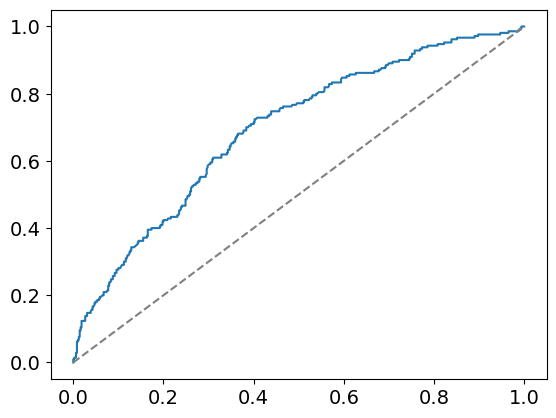

In [30]:
fpr,tpr,_ = roc_curve(y_train, lg2.predict(x_train2))
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],linestyle='--',color='grey')
plt.show();

In [31]:
auc_score = roc_auc_score(y_train, lg2.predict(x_train2))
auc_score

0.6936977648202138

### Final Predictions on Test Data

In [32]:
x_test = x_test.drop(columns=['Job_unskilled_and_non-resident',
                              'Housing_own',
                              'Job_skilled',
                              'Saving accounts_quite rich',
                              'Purpose_car',
                              'Purpose_vacation/others',
                              'Purpose_repairs',
                              'Housing_rent',
                              'Saving accounts_moderate',
                              'Purpose_domestic appliances',
                              'Purpose_education',
                              'Purpose_furniture/equipment',
                              'Credit amount',
                              'Checking account_rich'], axis=1)

In [33]:
pred_test = np.round(lg2.predict(x_test))

In [34]:
accuracy_score(y_test, pred_test)

0.72

In [35]:
cm = confusion_matrix(y_test, pred_test)
custom_cm = pd.DataFrame([[cm[1,1],cm[1,0]],
                          [cm[0,1],cm[0,0]]],
                         columns=['Predicted Positive','Predicted Negative'],
                         index=['Actual Positive','Actual Negative'])
custom_cm

,Predicted Positive,Predicted Negative
Actual Positive,22,68
Actual Negative,16,194


### Gaussian NB

In [36]:
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk,Purpose
0,67,male,skilled,own,little,little,1169,6,0,radio/TV
1,22,female,skilled,own,little,moderate,5951,48,1,radio/TV
2,49,male,unskilled_and_non-resident,own,little,little,2096,12,0,education
3,45,male,skilled,free,little,little,7882,42,0,furniture/equipment
4,53,male,skilled,free,little,little,4870,24,1,car


In [37]:
x_nb = df.drop(['Risk'], axis=1)
y_nb = df['Risk']
x_nb = pd.get_dummies(x_nb, drop_first=True)
x_train, x_test, y_train, y_test = train_test_split(x_nb, y_nb, test_size = 0.3, random_state = 1, stratify = y)

In [38]:
model = GaussianNB()
model.fit(x_train, y_train.ravel())

GaussianNB()

In [40]:
pred_train = model.predict(x_train)

In [41]:
print(classification_report(y_train, pred_train))

              precision    recall  f1-score   support

           0       0.76      0.79      0.77       490
           1       0.45      0.41      0.43       210

    accuracy                           0.67       700
   macro avg       0.61      0.60      0.60       700
weighted avg       0.67      0.67      0.67       700



In [42]:
cm = confusion_matrix(y_train, pred_train)
custom_cm = pd.DataFrame([[cm[1,1],cm[1,0]],
                          [cm[0,1],cm[0,0]]],
                         columns=['Predicted Positive','Predicted Negative'],
                         index=['Actual Positive','Actual Negative'])
custom_cm

,Predicted Positive,Predicted Negative
Actual Positive,87,123
Actual Negative,105,385
